# Survival probability vs propensity score 

**This notebook plots calibrated 6-month survival probability against propensity score for the mCRC cohort (pembrolizumab vs. chemotherapy).**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from iptw_survival import OverlapWeightSurvivalEstimator

from scipy import stats

## Import data 

### Import calibrated survival probabilities 

In [2]:
surv_pred_df = pd.read_csv('../outputs/gb_6m_survival_predictions_calibrated.csv')

In [3]:
surv_pred_df.head(3)

,PatientID,psurv_180_calibrated
0,F12B04C749133,0.690401
1,FFFB7D51F655C,0.840842
2,F6E393E2A3FBA,1.000000


In [4]:
surv_pred_df.shape

(1074, 2)

### Import treatment assignment

In [5]:
treatment_df = pd.read_csv('../outputs/pembro_chemo_index.csv')

In [6]:
treatment_df.shape

(26405, 3)

In [7]:
treatment_df.head(3)

,PatientID,LineName,StartDate
0,FFFB7D51F655C,pembro,2023-10-04
1,FB62DC3D3C20F,pembro,2025-06-05
2,F15B1F9F90957,pembro,2018-07-31


### Import features

In [8]:
dtype_map = pd.read_csv('../outputs/pembro_chemo_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/pembro_chemo_features_df.csv', dtype = dtype_map)

In [9]:
features_df.shape

(1208, 170)

### Import RMST pseudo-observations

In [10]:
pseudo_obs_df = pd.read_csv('../outputs/pseudo_obs_rmst.csv')

In [11]:
pseudo_obs_df.shape

(1074, 3)

In [12]:
pseudo_obs_df.head(3)

,PatientID,rmst_pseudo_1y,rmst_pseudo_2y
0,F12B04C749133,366.950404,740.005907
1,FFFB7D51F655C,366.950404,739.813368
2,F6E393E2A3FBA,366.950404,740.005907


### Merge dataframes

In [13]:
df = pd.merge(features_df, surv_pred_df, on = 'PatientID', how = 'left')

In [14]:
df.shape

(1208, 171)

In [15]:
df = pd.merge(df, pseudo_obs_df, on = 'PatientID', how = 'left')

In [16]:
df.shape

(1208, 173)

In [17]:
df = pd.merge(df, treatment_df, on = 'PatientID', how = 'left')

In [18]:
df.shape

(1208, 175)

In [19]:
df = df.query('met_diagnosis_year <= 2023')

In [20]:
df.shape

(1074, 175)

## Calculating overlap weights

In [21]:
df['treatment'] = np.where(df['LineName'] == 'pembro', 1, 0)

In [22]:
df.treatment.value_counts()

treatment
0    685
1    389
Name: count, dtype: int64

In [23]:
estimator = OverlapWeightSurvivalEstimator(normalize = None)

In [24]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['CrcSite'],
              cont_var = ['days_diagnosis_to_met', 'GroupStage_mod', 'ecog_index', 'ses_mod', 'age', 'percent_change_weight', 'hemoglobin', 'albumin', 'alp', 'cea', 'van_walraven_score'],
              binary_var = ['sex_male', 'ecog_index_na', 'ses_mod_na', 'medicaid', 'days_to_treatment_before_30d'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              use_missing_flags = False)

In [25]:
overlap_df = estimator.transform()

In [26]:
ps_fig = estimator.propensity_score_plot(bins = 30)

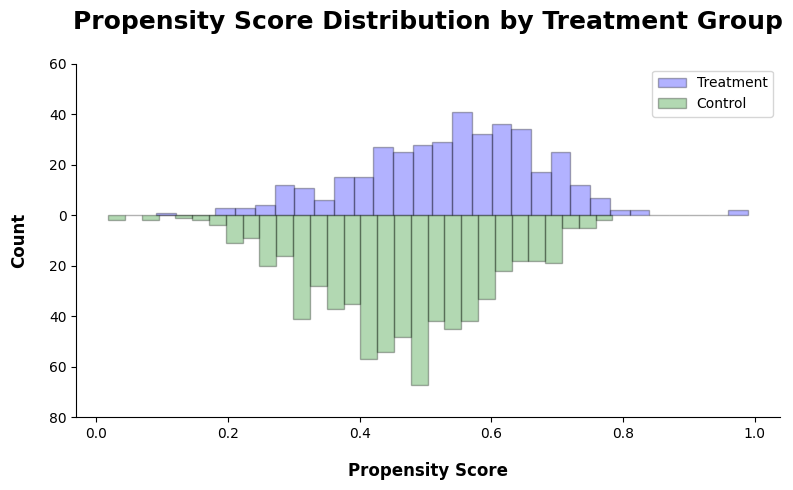

In [27]:
ps_fig

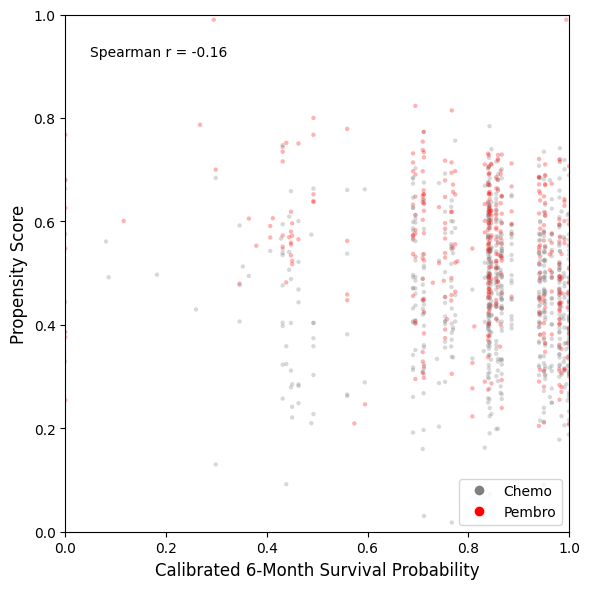

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))

colors = overlap_df['treatment'].map({0: 'gray', 1: 'red'})

ax.scatter(
    overlap_df['psurv_180_calibrated'],
    overlap_df['propensity_score'],
    c=colors,
    alpha=0.3,
    s=10,
    linewidths=0
)

# Correlation
r, _= stats.spearmanr(
    overlap_df['psurv_180_calibrated'],
    overlap_df['propensity_score']
)

ax.annotate(
    f'Spearman r = {r:.2f}',
    xy=(0.05, 0.92),
    xycoords='axes fraction',
    fontsize=10
)

ax.set_xlabel('Calibrated 6-Month Survival Probability', fontsize=12)
ax.set_ylabel('Propensity Score', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Chemo'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Pembro')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()